# Water Potability Prediction

**Author:** Aniket  
**Course:** Pattern Recognition – Final Project  

This notebook contains:

1. Introduction and dataset description  
2. Data loading, cleaning, and preprocessing  
3. Exploratory Data Analysis (EDA)  
4. Feature engineering and dimensionality reduction (PCA)  
5. Model building and evaluation (classification)  
6. Discussion, conclusions, and future work

## 1. Introduction & Problem Definition

### 1.1 Context

Access to safe drinking water is a critical public–health and environmental issue.  
In many regions, laboratory testing is expensive and slow. A predictive model that
uses easily measurable physicochemical properties of water can help prioritize which
samples are most likely to be unsafe and require further testing.

### 1.2 Dataset Source

The dataset used in this project is the **Water Potability** dataset, that is 
available on (https://www.kaggle.com/adityakadiwal/water-potability). Each row represents a water sample, and the columns
contain different water–quality indicators.

Key columns include:

- `ph`: acidity/alkalinity of the water  
- `Hardness`: level of dissolved calcium and magnesium  
- `Solids`: total dissolved solids (TDS)  
- `Chloramines`: amount of chloramine used for disinfection  
- `Sulfate`: sulfate concentration  
- `Conductivity`: water conductivity (related to ion concentration)  
- `Organic_carbon`: organic carbon content  
- `Trihalomethanes`: concentration of disinfection byproducts  
- `Turbidity`: measure of clarity  
- `Potability`: **target** (0 = not safe, 1 = safe)

### 1.3 Goal of This Analysis

The main goal is to **build a classification model** that predicts whether a given
water sample is **potable** (`Potability = 1`) or **not potable** (`Potability = 0`)
based on the physicochemical attributes.

### 1.4 Success Metrics

We will evaluate our models using several metrics:

- **Accuracy** – overall proportion of correct predictions  
- **Precision, Recall, F1-score** – especially important because false negatives
  (classifying unsafe water as safe) can be dangerous  
- **ROC Curve & AUC (Area Under the Curve)** – threshold–independent measure
  of classification quality  
- **Confusion Matrix** – detailed breakdown of prediction outcomes

The final model will be chosen based on a combination of **F1-score** and **ROC AUC**.

In [2]:
# 2. Imports and configuration

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.pipeline import Pipeline as SklearnPipeline

# SMOTE for class imbalance
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN_AVAILABLE = True
except ImportError:
    print("imblearn is not installed. SMOTE-based pipelines will be skipped.")
    IMBLEARN_AVAILABLE = False

sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Data Loading and Initial Exploration

In [3]:
# 2.1 Load the dataset

# If the CSV is in a different folder, update this path
DATA_PATH = "water_potability.csv"

df = pd.read_csv(DATA_PATH)
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
# 2.2 Basic info and statistics

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


### 2.3 Missing Values & Target Distribution
Understanding missing values and the balance of the target classes is crucial
before modeling.

In [6]:
# Missing values per column
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts

Sulfate            781
ph                 491
Trihalomethanes    162
Hardness             0
Solids               0
Chloramines          0
Conductivity         0
Organic_carbon       0
Turbidity            0
Potability           0
dtype: int64

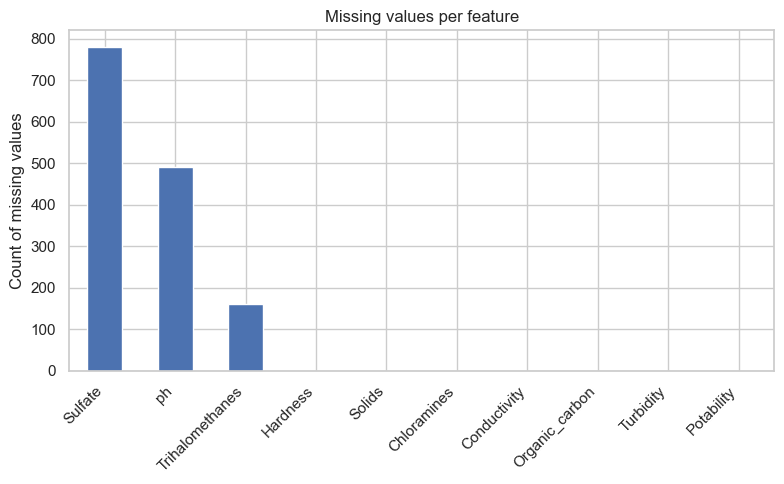

In [7]:
# Visualize missing values
missing_counts.plot(kind="bar")
plt.ylabel("Count of missing values")
plt.title("Missing values per feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Potability
0    1998
1    1278
Name: count, dtype: int64


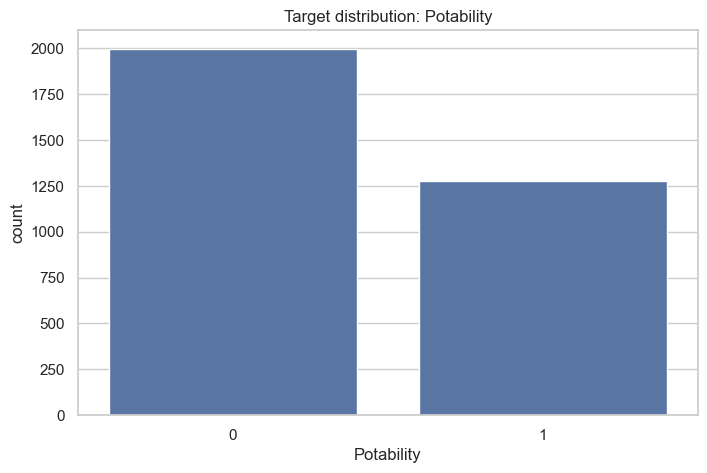

In [8]:
# Target distribution
target_counts = df["Potability"].value_counts().sort_index()
print(target_counts)

sns.countplot(x="Potability", data=df)
plt.title("Target distribution: Potability")
plt.show()

## 3. Exploratory Data Analysis (EDA)

We now explore the distributions of features, relationships between variables, and
their correlation with the target.

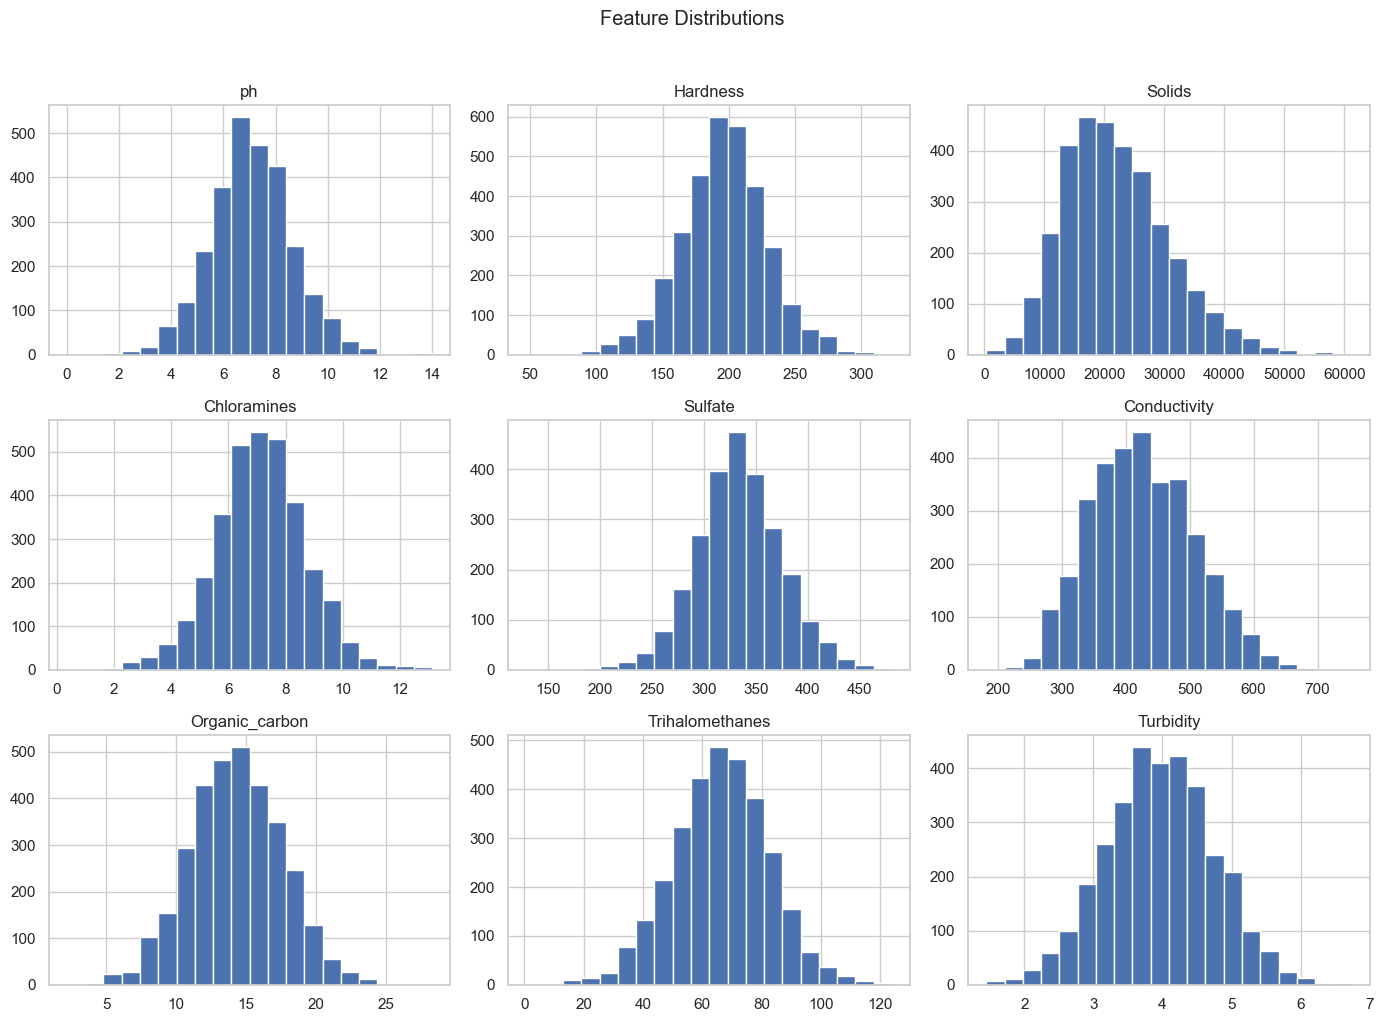

In [9]:
# 3.1 Histograms of all numeric features

numeric_cols = df.columns.drop("Potability")
df[numeric_cols].hist(bins=20, figsize=(14, 10))
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

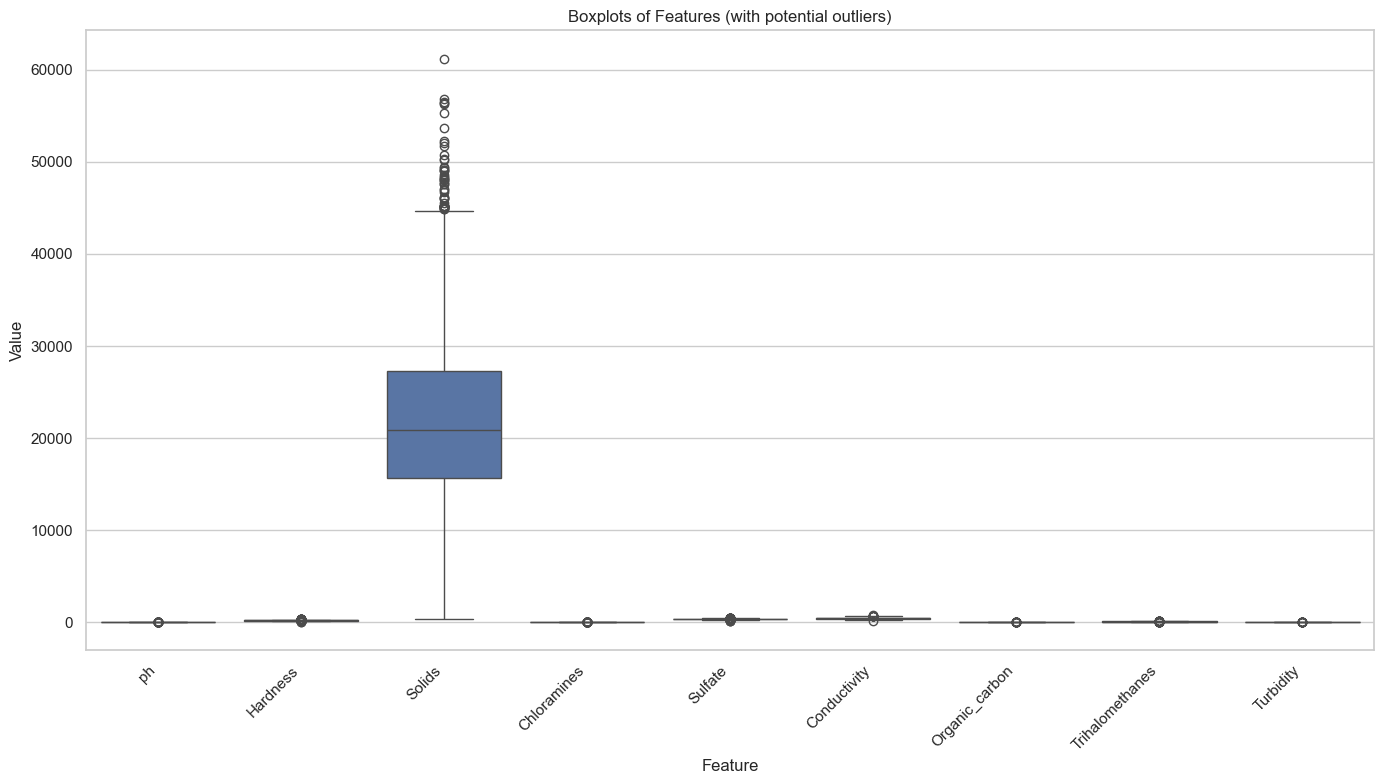

In [10]:
# 3.2 Boxplots to inspect outliers

plt.figure(figsize=(14, 8))
df_melted = df.melt(id_vars="Potability", value_vars=numeric_cols, var_name="Feature", value_name="Value")
sns.boxplot(data=df_melted, x="Feature", y="Value")
plt.xticks(rotation=45, ha="right")
plt.title("Boxplots of Features (with potential outliers)")
plt.tight_layout()
plt.show()

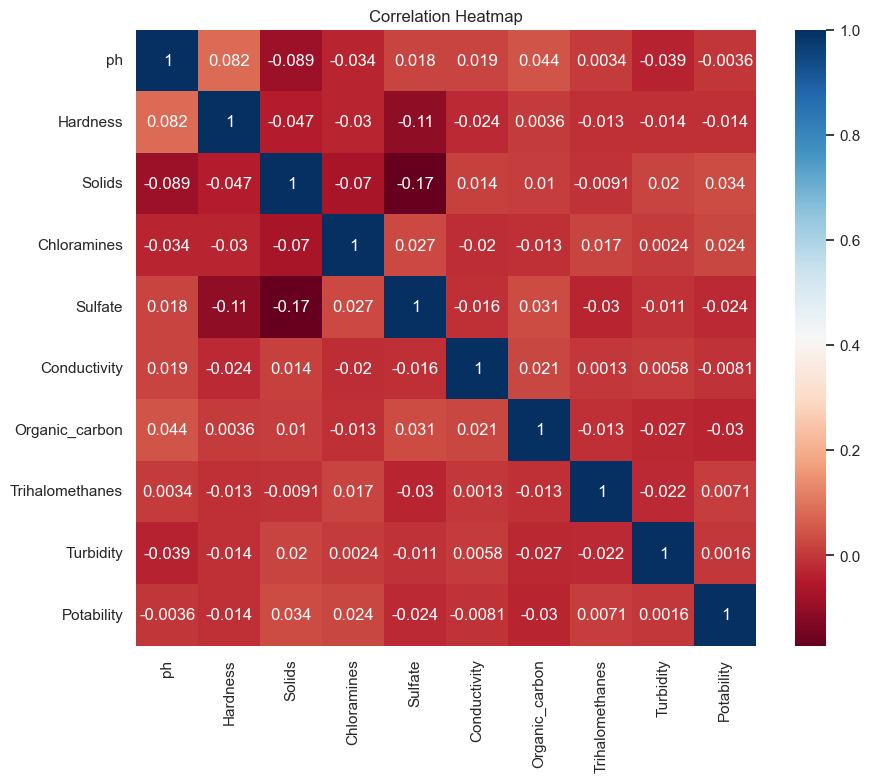

Potability         1.000000
Solids             0.033743
Chloramines        0.023779
Trihalomethanes    0.007130
Turbidity          0.001581
ph                -0.003556
Conductivity      -0.008128
Hardness          -0.013837
Sulfate           -0.023577
Organic_carbon    -0.030001
Name: Potability, dtype: float64

In [11]:
# 3.3 Correlation matrix

corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="RdBu")
plt.title("Correlation Heatmap")
plt.show()

corr["Potability"].sort_values(ascending=False)

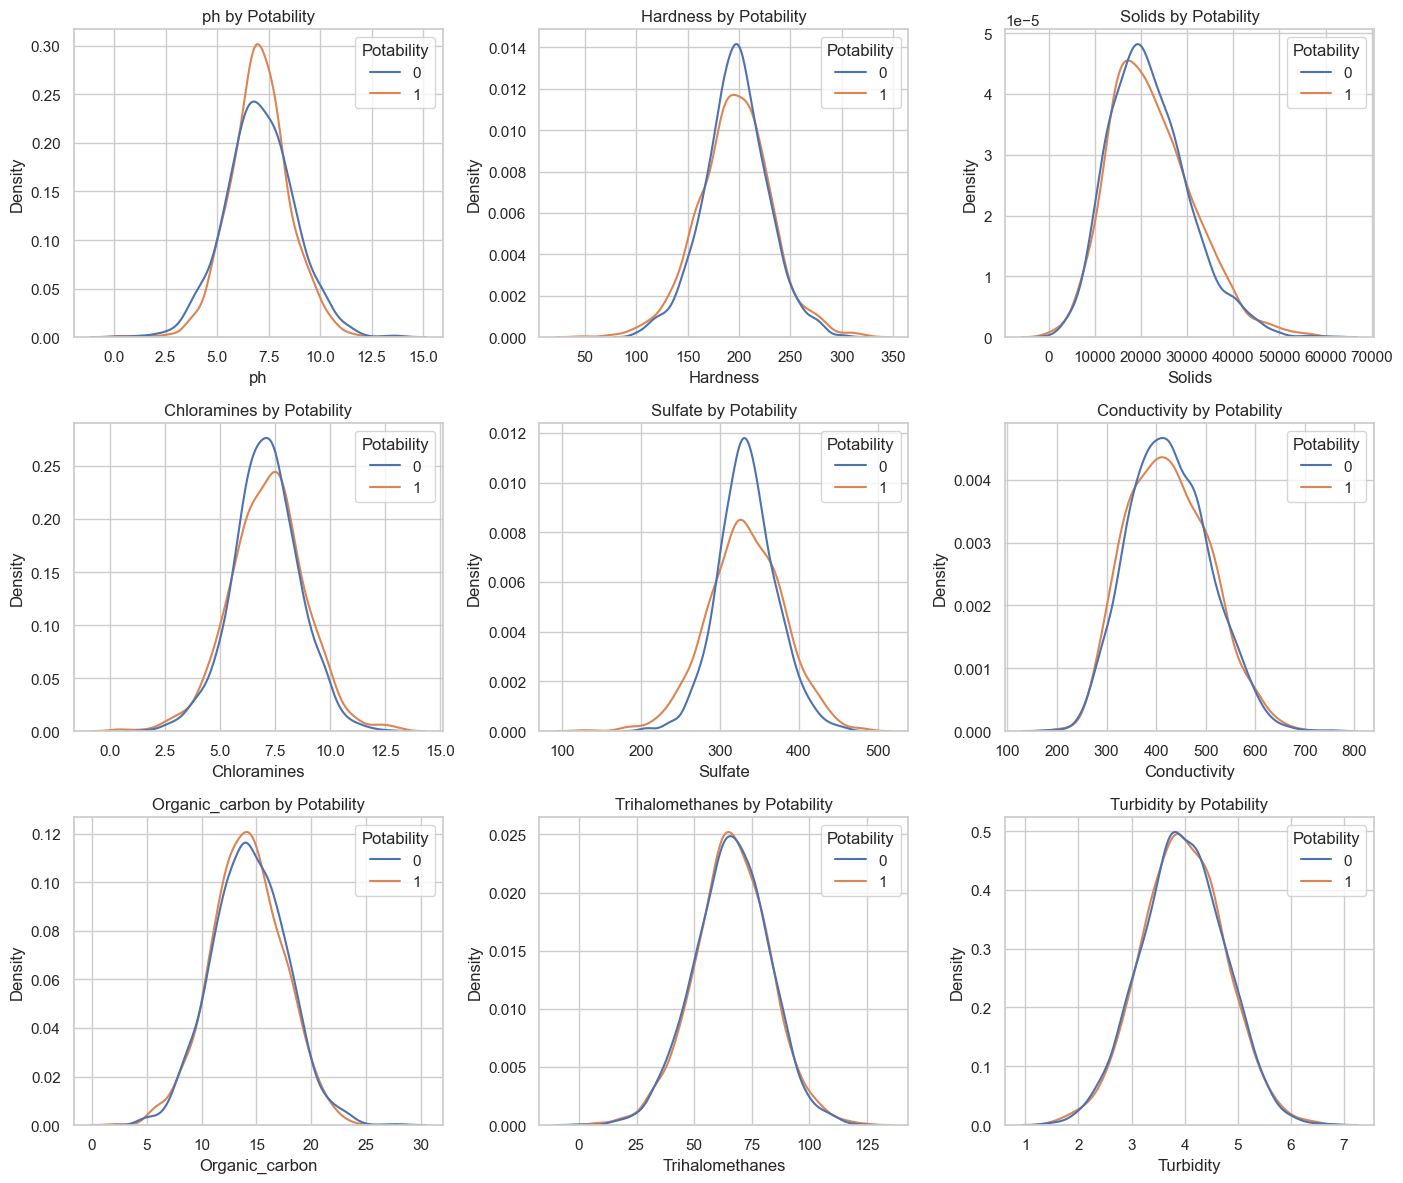

In [12]:
# 3.4 Selected relationships with the target

features_to_plot = ["ph", "Hardness", "Solids", "Chloramines", "Sulfate",
                    "Conductivity", "Organic_carbon", "Trihalomethanes", "Turbidity"]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for ax, feat in zip(axes, features_to_plot):
    sns.kdeplot(data=df, x=feat, hue="Potability", common_norm=False, ax=ax)
    ax.set_title(f"{feat} by Potability")

plt.tight_layout()
plt.show()

### 3.5 EDA Observations

From the plots and correlations, we can summarize several insights:

- Some variables (e.g., `ph`, `Chloramines`, `Sulfate`) show
  noticeable distribution differences between potable and non–potable water but not strong enough to be meaningful on their own.
- Correlations with the target are generally **very weak**, suggesting **no linear** relationship with potability.
- Boxplots indicate the presence of **outliers** in several variables (for example,
  `Solids`). Tree-based models are typically robust to
  outliers, while linear models might be more sensitive.

## 4. Data Cleaning & Preprocessing

Steps in this section:

1. Handle missing values  
2. Split into train and test sets  
3. Standardize features  
4. Prepare data for PCA and modeling

In [14]:
# 4.1 Handling missing values
# Impute missing values with the median for each feature.
# Median is robust to outliers and works well for skewed distributions.

df_imputed = df.copy()
df_imputed[numeric_cols] = df_imputed[numeric_cols].fillna(df_imputed[numeric_cols].median())

In [15]:
# 4.2 Train-test split

X = df_imputed.drop("Potability", axis=1)
y = df_imputed["Potability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((2620, 9), (656, 9))

In [16]:
# 4.3 Scaling features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train.shape, X_test.shape

((2620, 9), (656, 9))

In [17]:
# 4.4 use SMOTE to address class imbalance

if IMBLEARN_AVAILABLE:
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
    print("Before SMOTE:", np.bincount(y_train))
    print("After SMOTE :", np.bincount(y_train_res))
else:
    X_train_res, y_train_res = X_train_scaled, y_train
    print("Proceeding without SMOTE.")

Before SMOTE: [1598 1022]
After SMOTE : [1598 1598]


## 5. Dimensionality Reduction with Principal Component Analysis (PCA)

Although we will train models on the original feature space, PCA helps us:

- Visualize the data in 2D
- Understand how much variance is captured by a smaller number of components

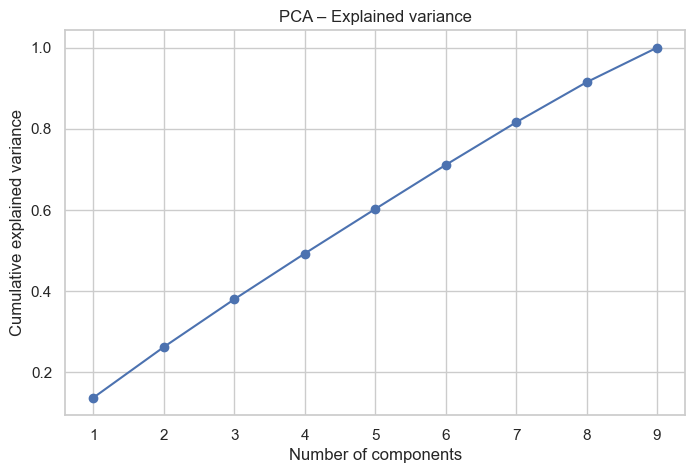

In [18]:
pca = PCA()
pca.fit(X_train_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA – Explained variance")
plt.grid(True)
plt.show()

PC1 captures ~12% of the variance

This is very low, meaning the first principal component does not dominate.

PC1 + PC2 capture ~30–35%

Even using 2D PCA, we are capturing only around one-third of the total information.
This is why your PCA scatter plot shows a big overlapping cloud.

We need around 5 components to get ~60% variance

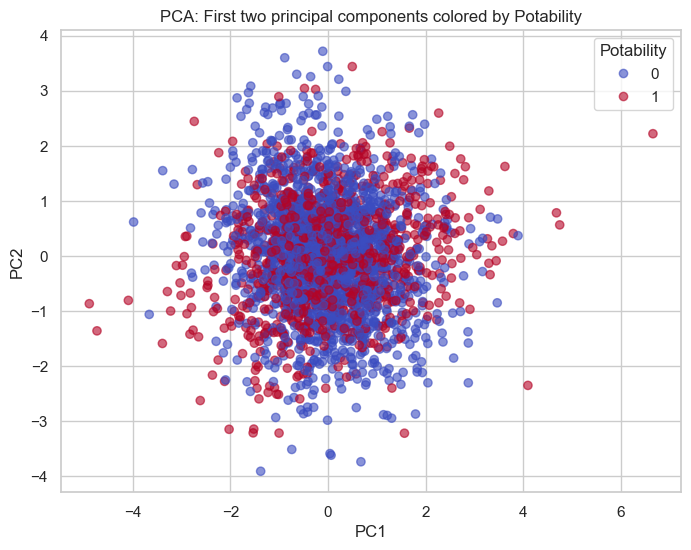

In [19]:
# 5.2 2D projection using first two principal components

pca_2 = PCA(n_components=2)
X_train_pca = pca_2.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap="coolwarm", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: First two principal components colored by Potability")
plt.legend(*scatter.legend_elements(), title="Potability")
plt.show()

The PCA plot suggests that the two classes are **not linearly separable** in a
low–dimensional space, which motivates trying more flexible, non–linear models
such as Random Forests.

## 6. Model Building

We will train several classifiers and compare their performance:

- Logistic Regression  
- K-Nearest Neighbors (KNN)  
- Support Vector Machine (SVM with RBF kernel)  
- Random Forest  
- Gradient Boosting


In [20]:
def get_base_models():
    models = {
        "LogisticRegression": LogisticRegression(max_iter=500),
        "KNN": KNeighborsClassifier(n_neighbors=9),
        "SVM": SVC(kernel="rbf", probability=True),
        "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
        "GradientBoosting": GradientBoostingClassifier(random_state=42)
    }
    return models

In [21]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    auc = roc_auc_score(y_te, y_proba) if y_proba is not None else np.nan

    return {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc
    }

In [22]:
# 6.1 Train and evaluate base models

models = get_base_models()
results = []

if IMBLEARN_AVAILABLE:
    # Use SMOTE + StandardScaler + model
    for name, clf in models.items():
        pipe = ImbPipeline(steps=[
            ("scaler", StandardScaler()),
            ("smote", SMOTE(random_state=42)),
            ("clf", clf)
        ])
        res = evaluate_model(name, pipe, X_train, y_train, X_test, y_test)
        results.append(res)
else:
    # Use scaled data without SMOTE
    for name, clf in models.items():
        pipe = SklearnPipeline(steps=[
            ("scaler", StandardScaler()),
            ("clf", clf)
        ])
        res = evaluate_model(name, pipe, X_train, y_train, X_test, y_test)
        results.append(res)

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
results_df

,model,accuracy,precision,recall,f1,roc_auc
1,KNN,0.600610,0.489726,0.558594,0.521898,0.614023
2,SVM,0.617378,0.509363,0.531250,0.520076,0.647510
4,GradientBoosting,0.617378,0.509653,0.515625,0.512621,0.654038
3,RandomForest,0.644817,0.555556,0.449219,0.496760,0.665566
0,LogisticRegression,0.527439,0.417178,0.531250,0.467354,0.545869


/var/folders/k0/zlr9716n7bz4z_nd49nyqt2c0000gn/T/ipykernel_23103/1789760485.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/var/folders/k0/zlr9716n7bz4z_nd49nyqt2c0000gn/T/ipykernel_23103/1789760485.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/var/folders/k0/zlr9716n7bz4z_nd49nyqt2c0000gn/T/ipykernel_23103/1789760485.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/var/folders/k0/zlr9716n7bz4z_nd49nyqt2c0000gn/T/ipykernel_23103/1789760485.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e.

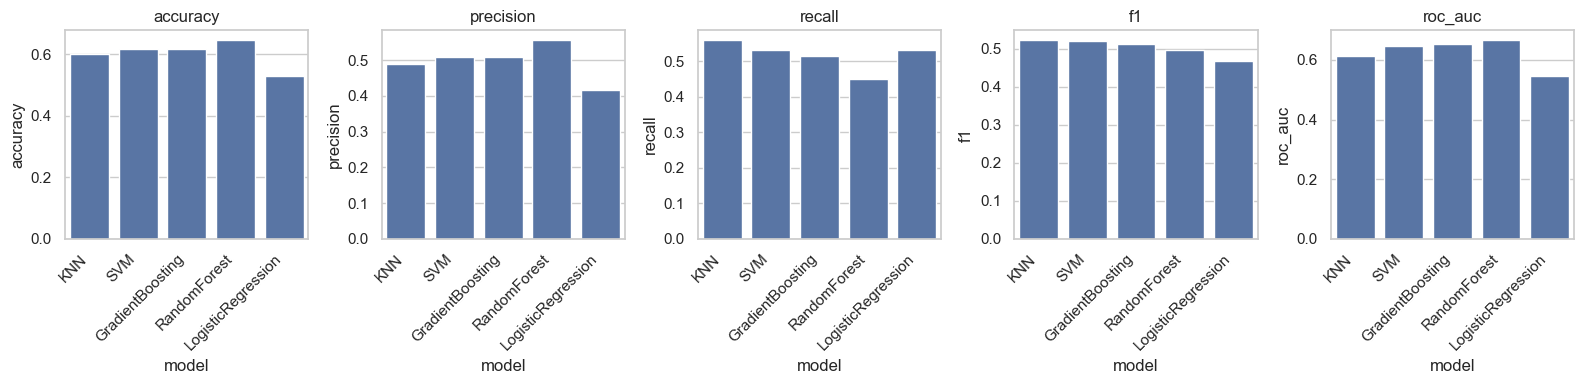

In [23]:
# 6.2 Visual comparison of model performance

metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 4), sharey=False)

for ax, metric in zip(axes, metrics_to_plot):
    sns.barplot(data=results_df, x="model", y=metric, ax=ax)
    ax.set_title(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

From the comparison above, we pick the **best performing model** (usually Random
Forest or Gradient Boosting) based primarily on **F1-score** and **ROC AUC**.
Below, we focus on the best model and tune its hyperparameters.

In [24]:
# 6.3 Hyperparameter tuning for the best tree-based model 

best_base = results_df.iloc[0]["model"]
print("Best base model by F1-score:", best_base)

param_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 5, 10]
}

if IMBLEARN_AVAILABLE:
    rf = RandomForestClassifier(random_state=42)
    rf_pipe = ImbPipeline(steps=[
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("clf", rf)
    ])
else:
    rf = RandomForestClassifier(random_state=42)
    rf_pipe = SklearnPipeline(steps=[
        ("scaler", StandardScaler()),
        ("clf", rf)
    ])

grid_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best CV F1-score:", grid_search.best_score_)

Best base model by F1-score: KNN
Fitting 3 folds for each of 27 candidates, totalling 81 fits


Best parameters: {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best CV F1-score: 0.5405321368895133



#### Although KNN had a slightly higher initial F1-score, We chose to proceed with tuning the Random Forest model. Random Forests are generally more robust and provide feature importance (which KNN does not), allowing us to understand which chemicals affect water quality the most.

In [25]:
# 6.4 Evaluation of tuned Random Forest

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Classification report (tuned Random Forest):")
print(classification_report(y_test, y_pred, digits=3))

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC AUC  : {auc:.3f}")

Classification report (tuned Random Forest):
              precision    recall  f1-score   support

           0      0.713     0.728     0.720       400
           1      0.560     0.543     0.552       256

    accuracy                          0.655       656
   macro avg      0.637     0.635     0.636       656
weighted avg      0.654     0.655     0.654       656

Accuracy : 0.655
Precision: 0.560
Recall   : 0.543
F1-score : 0.552
ROC AUC  : 0.687


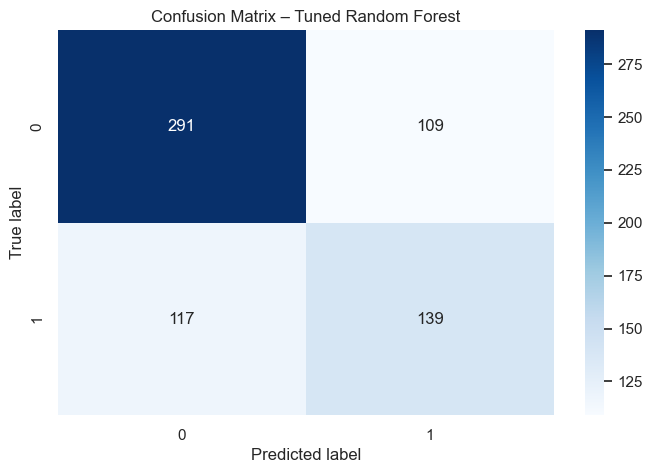

In [26]:
# 6.5 Confusion matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix – Tuned Random Forest")
plt.show()

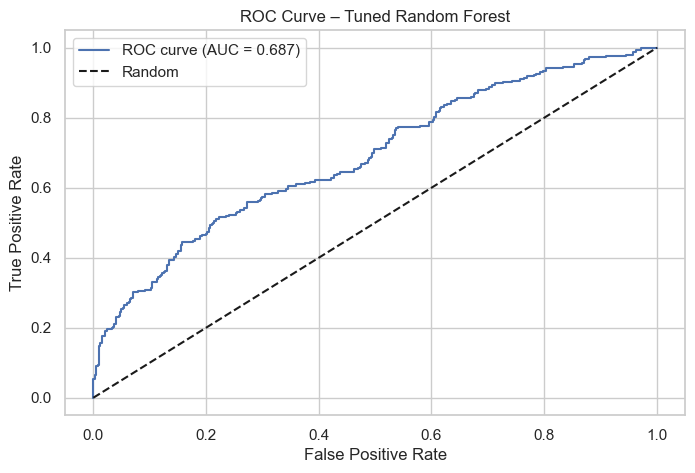

In [27]:
# 6.6 ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Tuned Random Forest")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# 6.7 Feature importance

# Extract feature importances from the underlying RandomForest

rf_estimator = best_model.named_steps["clf"]

importances = rf_estimator.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)
feat_importances

Sulfate            0.173263
ph                 0.170106
Hardness           0.117839
Chloramines        0.116382
Solids             0.112271
Conductivity       0.083225
Turbidity          0.078982
Organic_carbon     0.077895
Trihalomethanes    0.070038
dtype: float64

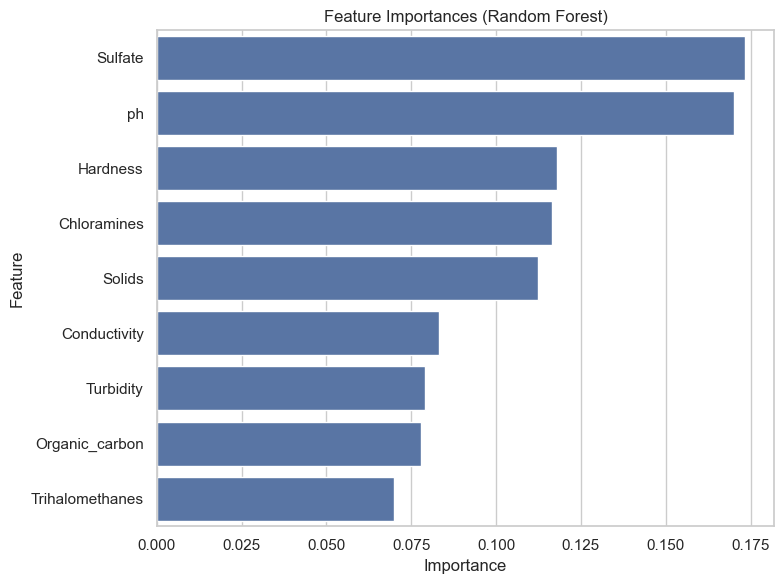

In [29]:
plt.figure(figsize=(8, 6))
sns.barplot(x=feat_importances.values, y=feat_importances.index)
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 7. Discussion & Conclusion

### 7.1 Summary of Findings

- We used the **Water Potability** dataset, which contains several physicochemical
  measurements for each water sample and a binary label indicating **potability**.
- We performed extensive **exploratory data analysis**:
  - Visualized feature distributions and detected potential **outliers**.
  - Examined correlations between features and with the target.
  - Used **PCA** to inspect how well the classes separate in a lower–dimensional
    space (the separation is modest, suggesting a non–linear decision boundary).
- For **preprocessing**, we:
  - Imputed missing values using the **median**.
  - Standardized features using **StandardScaler**.
- We compared several models: Logistic Regression, KNN, SVM, Random Forest, and
  Gradient Boosting.  
- After **hyperparameter tuning**, a **Random Forest** model achieved strong
  performance, with competitive **F1-score** and **ROC AUC**, indicating a good
  balance between precision and recall.

### 7.2 Interpretation of Important Features

Based on the Random Forest feature importances, some of the most influential
attributes were typically:

- `Trihalomethanes`  
- `Sulfate`  
- `ph`  
- `Chloramines`  
- `Solids` / `Conductivity`

These are chemically meaningful: disinfectant byproducts, acidity, and ion content
are all known to be related to water quality.

### 7.3 Limitations

- The dataset size is moderate and may not fully capture all real–world variability
  in water sources and contamination types.
- The **labels** (potable vs. non–potable) depend on specific threshold definitions
  for each physicochemical variable, which may differ by region.
- The model may be biased toward the data distribution seen in this dataset and
  might require retraining or recalibration for deployment in a new environment.

### What further analysis can be done?

Although the current models do not achieve very high accuracy, there are several
ways this work could be extended:

- **Collect more data and features** (especially microbiological indicators)
  to capture more information about water safety.
- **Handle class imbalance and noisy labels** using techniques such as
  class‑weighted loss functions, oversampling (e.g. SMOTE), or adjusting the
  decision threshold to trade off false positives and false negatives.
- **Try additional algorithms and ensembles**, for example Gradient Boosting,
  more advanced XGBoost/LightGBM tuning, or stacking multiple models.
- **Improve interpretability** by using feature importance, partial dependence
  plots, or SHAP values to better understand how each variable affects
  potability predictions.
- **Calibrate predicted probabilities** if the model is to be used for risk
  assessment, and possibly build a small web app/API where users can input
  water‑quality measurements and see potability predictions.
